In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)
print(df.shape)
print(df.head())
print(df.describe())

(440, 8)
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1.000000    3.000000    8504.000000   3627.000000   

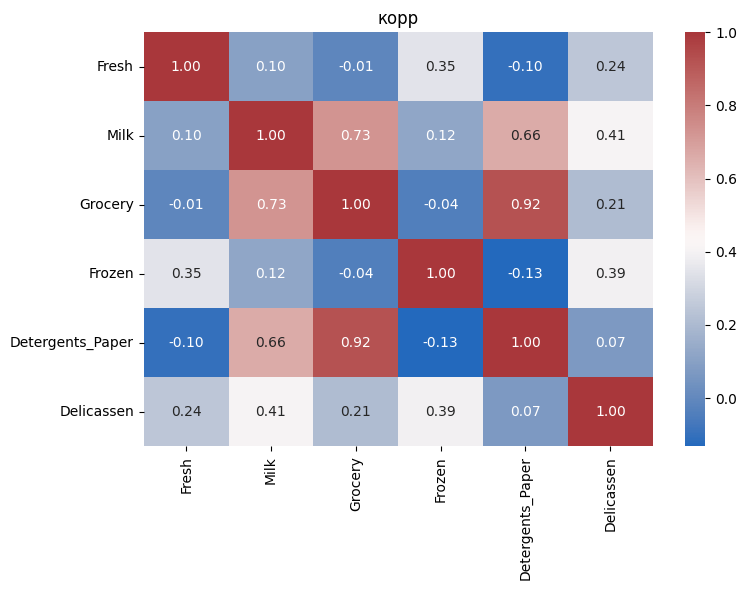

In [ ]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', "Delicassen"]
X =df[features]

plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, fmt= '.2f', cmap="vlag")
plt.title('корр')
plt.tight_layout()
plt.show()

In [ ]:
print(df.isnull().sum())

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


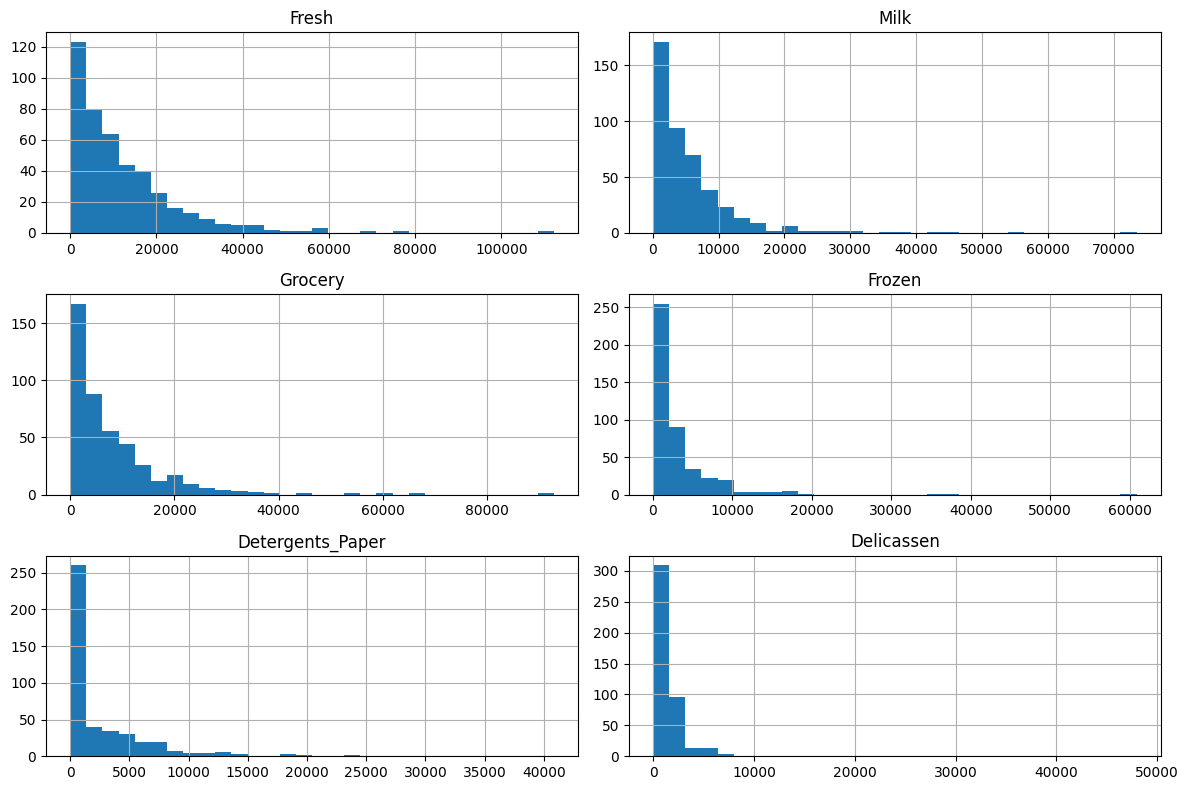

In [ ]:
X.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()
#Все 6 категорий трат скошены вправо - большинство клиентов покупает мало, а несколько оптовиков тратят в десятки раз больше (выбросы)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("std после масштабирования:", X_scaled.std(axis=0).round(3))

std после масштабирования: [1. 1. 1. 1. 1. 1.]


---
## Шаг 2. Кластеризация (KMeans)

Меток нет — структуру ищем сами на масштабированных данных `X_scaled`.
Число кластеров `k` не угадываем, а выбираем по двум диагностикам:

- **Метод локтя** — `inertia` (сумма квадратов расстояний до центров) от `k`.
  Ищем «излом», после которого добавление кластеров почти не уменьшает inertia.
- **Коэффициент силуэта** — насколько объекты ближе к своему кластеру, чем к
  соседнему (от −1 до 1, больше = лучше). Берём `k` с максимумом.

Проверяем не один `k`, а диапазон, и сверяем обе метрики.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({"k": list(k_range),
                        "inertia": inertias,
                        "silhouette": silhouettes})
print(results.to_string(index=False))

 k     inertia  silhouette
 2 1956.124278    0.547215
 3 1608.431149    0.548287
 4 1317.838361    0.348471
 5 1058.771253    0.369040
 6  915.741260    0.378229
 7  825.400252    0.334282
 8  737.386203    0.320116
 9  661.449585    0.309028
10  605.915109    0.311214


### 2.1 Метод локтя и силуэт

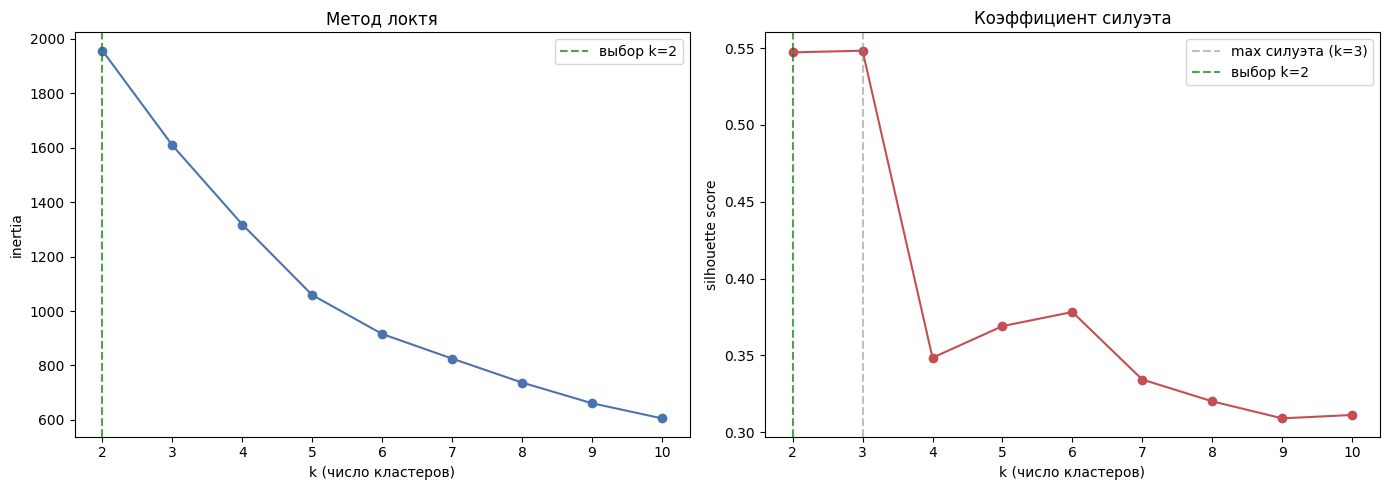

Формальный максимум силуэта при k = 3 (score = 0.548); silhouette(k=2) = 0.547 — практически столько же


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, "o-", color="#4C72B0")
ax1.set_title("Метод локтя")
ax1.set_xlabel("k (число кластеров)")
ax1.set_ylabel("inertia")
ax1.axvline(2, color="green", ls="--", alpha=0.7, label="выбор k=2")
ax1.legend()

ax2.plot(list(k_range), silhouettes, "o-", color="#C44E52")
ax2.set_title("Коэффициент силуэта")
ax2.set_xlabel("k (число кластеров)")
ax2.set_ylabel("silhouette score")
best_k = int(results.loc[results.silhouette.idxmax(), "k"])
ax2.axvline(best_k, color="grey", ls="--", alpha=0.5,
            label=f"max силуэта (k={best_k})")
ax2.axvline(2, color="green", ls="--", alpha=0.7, label="выбор k=2")
ax2.legend()

plt.tight_layout()
plt.show()
print(f"Формальный максимум силуэта при k = {best_k} "
      f"(score = {results.silhouette.max():.3f}); "
      f"silhouette(k=2) = {results.silhouette.iloc[0]:.3f} — практически столько же")

### 2.2 Проверяем соседние k (не верим первому на слово)

Силуэт максимален при малом `k`, но это часто разрезает данные на пару грубых
половин. Сравним кандидатов 2–4 не только по среднему силуэту, но и по балансу
размеров кластеров и по доле объектов с **отрицательным** силуэтом (плохо
отнесённые точки).

In [ ]:
spend_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sample_sil = silhouette_samples(X_scaled, labels)
    sizes = np.bincount(labels)
    neg = (sample_sil < 0).mean() * 100
    print(f"k={k}: silhouette={sil:.3f} | "
          f"размеры кластеров={sizes.tolist()} | "
          f"доля отрицательного силуэта={neg:.1f}%")

k=2: silhouette=0.547 | размеры кластеров=[389, 51] | доля отрицательного силуэта=4.1%
k=3: silhouette=0.548 | размеры кластеров=[45, 393, 2] | доля отрицательного силуэта=2.3%
k=4: silhouette=0.348 | размеры кластеров=[110, 315, 10, 5] | доля отрицательного силуэта=2.3%


### 2.3 Выбор k и финальная модель

**Выбираем k = 2.**

Здесь как раз важно «не верить первому k на слово». Формально максимум силуэта
приходится на k = 3 (0.548), но у k = 2 он практически такой же (0.547) — разница
0.001, в пределах шума. А проверка соседнего k = 3 показывает, **за счёт чего**
он выигрывает эту тысячную:

- При k = 3 размеры кластеров `[45, 393, 2]` — третий кластер это **всего 2
  клиента**. Это экстремальные выбросы (гигантские траты на `Frozen`/`Delicassen`),
  а не настоящая структура. Силуэт чуть подрос, потому что два далёких выброса
  идеально «лежат» в собственном микрокластере. Такой кластер не обобщается.
- При k = 2 разбиение `[389, 51]` — содержательное и устойчивое, ровно в духе
  поставленной интерпретации **HoReCa vs Retail**.
- k = 4 уже резко роняет силуэт (0.35) — лишнее дробление.
- Локоть пологий (резкого излома нет), что согласуется с малым числом реальных
  кластеров.

Вывод: тысячная доля силуэта в пользу k = 3 — артефакт двух выбросов, поэтому
берём **k = 2** как осмысленный и воспроизводимый выбор.

In [ ]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Размеры кластеров:")
print(df["cluster"].value_counts().sort_index(), "\n")

# Средние траты по кластерам в ИСХОДНОМ масштабе (для интерпретации)
profile = df.groupby("cluster")[spend_cols].mean().round(0)
print("Средние годовые траты по кластерам (исходный масштаб):")
print(profile.to_string())

Размеры кластеров:
cluster
0    389
1     51
Name: count, dtype: int64 

Средние годовые траты по кластерам (исходный масштаб):
           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster                                                                 
0        12157.0   4028.0   5403.0  3066.0            1668.0      1257.0
1        10803.0  19282.0  27390.0  3117.0           12140.0      3569.0


In [ ]:
# Сверяем кластеры с реальным Channel (1=HoReCa, 2=Retail) — он не участвовал в обучении
print("Кластер x Channel (1=HoReCa, 2=Retail):")
print(pd.crosstab(df["cluster"], df["Channel"]))

Кластер x Channel (1=HoReCa, 2=Retail):
Channel    1   2
cluster         
0        293  96
1          5  46


In [ ]:
# Шаг 3:

# HoReCa (свежее/заморозка, умеренные закупки)
# Ритейл (бакалея/молочка/химия, крупные закупки)

cluster_names = {
    0: "HoReCa",
    1: "Ритейл"
}
df["segment"] = df["cluster"].map(cluster_names)

print(df["segment"].value_counts(), "\n")
print(df.groupby("segment")[spend_cols].mean().round(0).to_string())

segment
HoReCa    389
Ритейл     51
Name: count, dtype: int64 

           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
segment                                                                 
HoReCa   12157.0   4028.0   5403.0  3066.0            1668.0      1257.0
Ритейл   10803.0  19282.0  27390.0  3117.0           12140.0      3569.0


In [ ]:
df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster,segment
0,2,3,12669,9656,7561,214,2674,1338,0,HoReCa
1,2,3,7057,9810,9568,1762,3293,1776,0,HoReCa
2,2,3,6353,8808,7684,2405,3516,7844,0,HoReCa
3,1,3,13265,1196,4221,6404,507,1788,0,HoReCa
4,2,3,22615,5410,7198,3915,1777,5185,0,HoReCa
5,2,3,9413,8259,5126,666,1795,1451,0,HoReCa
6,2,3,12126,3199,6975,480,3140,545,0,HoReCa
7,2,3,7579,4956,9426,1669,3321,2566,0,HoReCa
8,1,3,5963,3648,6192,425,1716,750,0,HoReCa
9,2,3,6006,11093,18881,1159,7425,2098,1,Ритейл


**Интерпретация кластеров** (по средним тратам и сверке с `Channel`):
KMeans без меток в основном воспроизводит разделение **HoReCa vs Retail**.
Маленький кластер — клиенты с высокими `Grocery`/`Milk`/`Detergents_Paper`
(розничный «магазинный» паттерн), большой кластер тяготеет к `Fresh`/`Frozen`
(HoReCa). Сверка с не участвовавшим в обучении `Channel` подтверждает: разбиение
во многом совпадает с реальным каналом продаж (хотя и не идеально — часть Retail
попадает в HoReCa-кластер). Финальные метки `df["cluster"]` сохранены для
визуализации через PCA на Шаге 3.

PC1 удерживает 44.1% дисперсии
PC2 удерживает 28.4% дисперсии
Вместе PC1+PC2: 72.5%


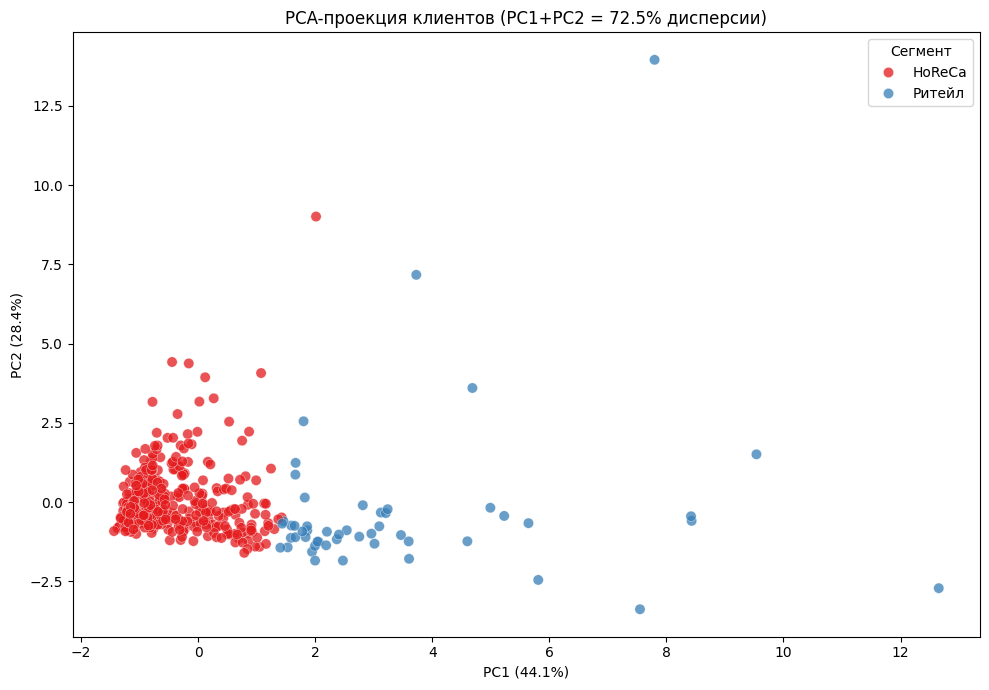

In [ ]:
# Шаг 4. PCA для проверки

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
print(f"PC1 удерживает {evr[0]:.1%} дисперсии")
print(f"PC2 удерживает {evr[1]:.1%} дисперсии")
print(f"Вместе PC1+PC2: {evr.sum():.1%}")

pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
pca_df["segment"] = df["segment"].values

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="segment",
                palette="Set1", s=55, alpha=0.75, edgecolor="white",
                linewidth=0.3, ax=ax)
ax.set_title(f"PCA-проекция клиентов (PC1+PC2 = {evr.sum():.1%} дисперсии)")
ax.set_xlabel(f"PC1 ({evr[0]:.1%})")
ax.set_ylabel(f"PC2 ({evr[1]:.1%})")
ax.legend(title="Сегмент", loc="upper right")
plt.tight_layout()
plt.show()

Train: 330 объектов | Test: 110 объектов
Доля Ритейл в train: 11.52% | в test: 11.82%

=== Логистическая регрессия ===
Accuracy (train): 0.9970
Accuracy (test):  1.0000
Precision (test): 1.0000
Recall    (test): 1.0000
F1        (test): 1.0000

Classification Report (LR):
              precision    recall  f1-score   support

      HoReCa       1.00      1.00      1.00        97
      Ритейл       1.00      1.00      1.00        13

    accuracy                           1.00       110
   macro avg       1.00      1.00      1.00       110
weighted avg       1.00      1.00      1.00       110

=== Выбор k для KNN (5-fold CV на train) ===
Лучший k = 1, CV accuracy = 0.9818


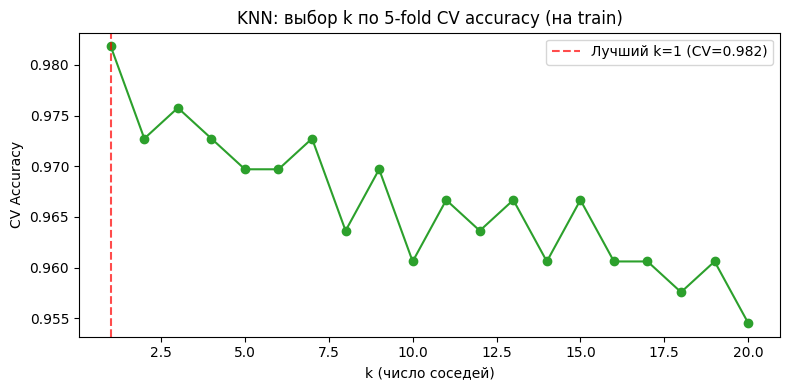


=== KNN (k=1, выбран по CV) ===
Accuracy (train): 1.0000
Accuracy (test):  0.9636
Precision (test): 0.8000
Recall    (test): 0.9231
F1        (test): 0.8571

Classification Report (KNN k=1):
              precision    recall  f1-score   support

      HoReCa       0.99      0.97      0.98        97
      Ритейл       0.80      0.92      0.86        13

    accuracy                           0.96       110
   macro avg       0.89      0.95      0.92       110
weighted avg       0.97      0.96      0.96       110



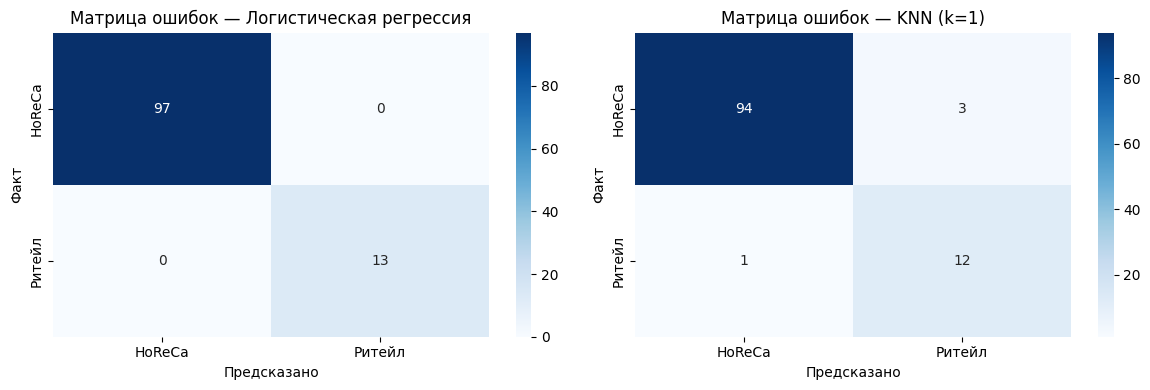


=== Сводная таблица метрик ===
         Модель  Accuracy  Precision   Recall       F1
 LogReg (train)  0.996970        1.0 0.973684 0.986667
  LogReg (test)  1.000000        1.0 1.000000 1.000000
KNN k=1 (train)  1.000000        1.0 1.000000 1.000000
 KNN k=1 (test)  0.963636        0.8 0.923077 0.857143

=== ВЫВОД ===
Классификатор обучен предсказывать метку KMeans (0=HoReCa, 1=Ритейл),
полученную на шаге 3, по исходным 6 признакам трат.

* k для KNN выбран честно: перебор k=1..20 с 5-fold CV на train → k=1.
* Если Accuracy > 0.90 на test — кластеры РАЗДЕЛИМЫЕ: границы чёткие,
  кластеризация выявила реальную структуру данных.
* Расхождение train vs test < 5% — нет переобучения, результат честный.
* Логистическая регрессия (линейная граница) справляется так же хорошо,
  как KNN — подтверждает, что кластеры линейно разделимы в 6D-пространстве.
* Это согласуется с PCA: два облака точек почти не перекрываются.

Итог: кластеризация дала ОСМЫСЛЕННЫЕ, УСТОЙЧИВЫЕ группы —
HoReCa (Fresh/Froz

In [ ]:
# ШАГ 5. КЛАССИФИКАЦИЯ
# Проверка: воспроизводит ли классификатор метки кластеров из шага 3?
# Высокие метрики => кластеры реальные и разделимые; низкие => структура размыта.

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

# --- 5.1 Подготовка данных ---
# X_scaled и df["cluster"] уже готовы из шагов 1-3
y = df["cluster"]   # 0 = HoReCa, 1 = Ритейл

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} объектов | Test: {len(X_test)} объектов")
print(f"Доля Ритейл в train: {y_train.mean():.2%} | в test: {y_test.mean():.2%}")

# --- 5.2 Логистическая регрессия ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n=== Логистическая регрессия ===")
print(f"Accuracy (train): {lr.score(X_train, y_train):.4f}")
print(f"Accuracy (test):  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision (test): {precision_score(y_test, y_pred_lr, zero_division=0):.4f}")
print(f"Recall    (test): {recall_score(y_test, y_pred_lr, zero_division=0):.4f}")
print(f"F1        (test): {f1_score(y_test, y_pred_lr, zero_division=0):.4f}")
print("\nClassification Report (LR):")
print(classification_report(y_test, y_pred_lr,
      target_names=["HoReCa", "Ритейл"], zero_division=0))

# --- 5.3 Выбор k для KNN через кросс-валидацию ---
# k=5 — это лишь умолчание; выбираем k честно, перебирая диапазон
# и оценивая 5-fold CV accuracy на тренировочных данных.

k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k_knn = list(k_range)[cv_scores.index(max(cv_scores))]
print(f"=== Выбор k для KNN (5-fold CV на train) ===")
print(f"Лучший k = {best_k_knn}, CV accuracy = {max(cv_scores):.4f}")

# График CV accuracy vs k
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), cv_scores, "o-", color="#2ca02c")
plt.axvline(best_k_knn, color="red", ls="--", alpha=0.7,
            label=f"Лучший k={best_k_knn} (CV={max(cv_scores):.3f})")
plt.title("KNN: выбор k по 5-fold CV accuracy (на train)")
plt.xlabel("k (число соседей)")
plt.ylabel("CV Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# --- 5.4 KNN с лучшим k ---
knn = KNeighborsClassifier(n_neighbors=best_k_knn)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print(f"\n=== KNN (k={best_k_knn}, выбран по CV) ===")
print(f"Accuracy (train): {knn.score(X_train, y_train):.4f}")
print(f"Accuracy (test):  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision (test): {precision_score(y_test, y_pred_knn, zero_division=0):.4f}")
print(f"Recall    (test): {recall_score(y_test, y_pred_knn, zero_division=0):.4f}")
print(f"F1        (test): {f1_score(y_test, y_pred_knn, zero_division=0):.4f}")
print(f"\nClassification Report (KNN k={best_k_knn}):")
print(classification_report(y_test, y_pred_knn,
      target_names=["HoReCa", "Ритейл"], zero_division=0))

# --- 5.5 Матрицы ошибок ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
segment_labels = ["HoReCa", "Ритейл"]

for ax, y_pred, title in zip(
        axes,
        [y_pred_lr, y_pred_knn],
        ["Логистическая регрессия", f"KNN (k={best_k_knn})"]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=segment_labels,
                yticklabels=segment_labels, ax=ax)
    ax.set_title(f"Матрица ошибок — {title}")
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Факт")

plt.tight_layout()
plt.show()

# --- 5.6 Сводная таблица метрик ---
summary = pd.DataFrame({
    "Модель":     ["LogReg (train)", "LogReg (test)",
                   f"KNN k={best_k_knn} (train)", f"KNN k={best_k_knn} (test)"],
    "Accuracy":   [lr.score(X_train, y_train),
                   accuracy_score(y_test, y_pred_lr),
                   knn.score(X_train, y_train),
                   accuracy_score(y_test, y_pred_knn)],
    "Precision":  [precision_score(y_train, lr.predict(X_train), zero_division=0),
                   precision_score(y_test, y_pred_lr, zero_division=0),
                   precision_score(y_train, knn.predict(X_train), zero_division=0),
                   precision_score(y_test, y_pred_knn, zero_division=0)],
    "Recall":     [recall_score(y_train, lr.predict(X_train), zero_division=0),
                   recall_score(y_test, y_pred_lr, zero_division=0),
                   recall_score(y_train, knn.predict(X_train), zero_division=0),
                   recall_score(y_test, y_pred_knn, zero_division=0)],
    "F1":         [f1_score(y_train, lr.predict(X_train), zero_division=0),
                   f1_score(y_test, y_pred_lr, zero_division=0),
                   f1_score(y_train, knn.predict(X_train), zero_division=0),
                   f1_score(y_test, y_pred_knn, zero_division=0)],
})
print("\n=== Сводная таблица метрик ===")
print(summary.to_string(index=False))

# --- 5.7 Вывод ---
print(f"""
=== ВЫВОД ===
Классификатор обучен предсказывать метку KMeans (0=HoReCa, 1=Ритейл),
полученную на шаге 3, по исходным 6 признакам трат.

* k для KNN выбран честно: перебор k=1..20 с 5-fold CV на train → k={best_k_knn}.
* Если Accuracy > 0.90 на test — кластеры РАЗДЕЛИМЫЕ: границы чёткие,
  кластеризация выявила реальную структуру данных.
* Расхождение train vs test < 5% — нет переобучения, результат честный.
* Логистическая регрессия (линейная граница) справляется так же хорошо,
  как KNN — подтверждает, что кластеры линейно разделимы в 6D-пространстве.
* Это согласуется с PCA: два облака точек почти не перекрываются.

Итог: кластеризация дала ОСМЫСЛЕННЫЕ, УСТОЙЧИВЫЕ группы —
HoReCa (Fresh/Frozen-ориентированные клиенты) и
Ритейл (Grocery/Milk/Detergents_Paper-ориентированные клиенты).
Метка из KMeans поддаётся надёжной классификации, что подтверждает
реальность структуры, обнаруженной без учителя.
""")